This notebook generates Sales Analytics Visualizations. It reads from gold layer and creates charts

In [1]:
# Import the necessary libraries 
from pyspark.sql import SparkSession
from pathlib import Path
import src.sqlqueries as sq
import sys
import os
import warnings
import utils.logger as logger
from pyspark.sql import functions as F
from pyspark.sql.functions import to_timestamp, col
from pyspark.sql.functions import sum as spark_sum, when, count, countDistinct

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")


# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


#Set the path for logging outputs
job_name = "visualizations"
data_base_path = Path("../Logs") # path for logging data
data_working_path = os.path.join(data_base_path, job_name) 
os.makedirs(data_working_path, exist_ok=True)
logger.set_logging_path(data_working_path)

# Spark initialization locally for development
spark = (
    SparkSession.builder
    .appName("sales-analytics-visuals")
    .getOrCreate()
)

logger.log("Spark Session initialized")
logger.log("Reading gold layer data...")

# Read monthly data
monthly_df = spark.read.parquet("../data/gold/sales_monthly").toPandas()
logger.log(f"Monthly data loaded: {len(monthly_df)} rows")

# Read product data
product_df = spark.read.parquet("../data/gold/sales_products").toPandas()
logger.log(f"Product data loaded: {len(product_df)} rows")

# Read quarterly data
quarterly_df = spark.read.parquet("../data/gold/sales_quarterly").toPandas()
logger.log(f"Quarterly data loaded: {len(quarterly_df)} rows")
logger.log("Spark DataFrame created from silver - cleansed sales parquet files")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/02/05 01:07:44 WARN Utils: Your hostname, gvidias, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/02/05 01:07:44 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/05 01:07:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


2026-02-05 01:07:57: Spark Session initialized
2026-02-05 01:07:57: Reading gold layer data...
2026-02-05 01:07:59: Monthly data loaded: 13 rows
2026-02-05 01:07:59: Product data loaded: 19 rows
2026-02-05 01:07:59: Quarterly data loaded: 5 rows
2026-02-05 01:07:59: Spark DataFrame created from silver - cleansed sales parquet files


2026-02-05 01:08:09: Creating monthly revenue chart...


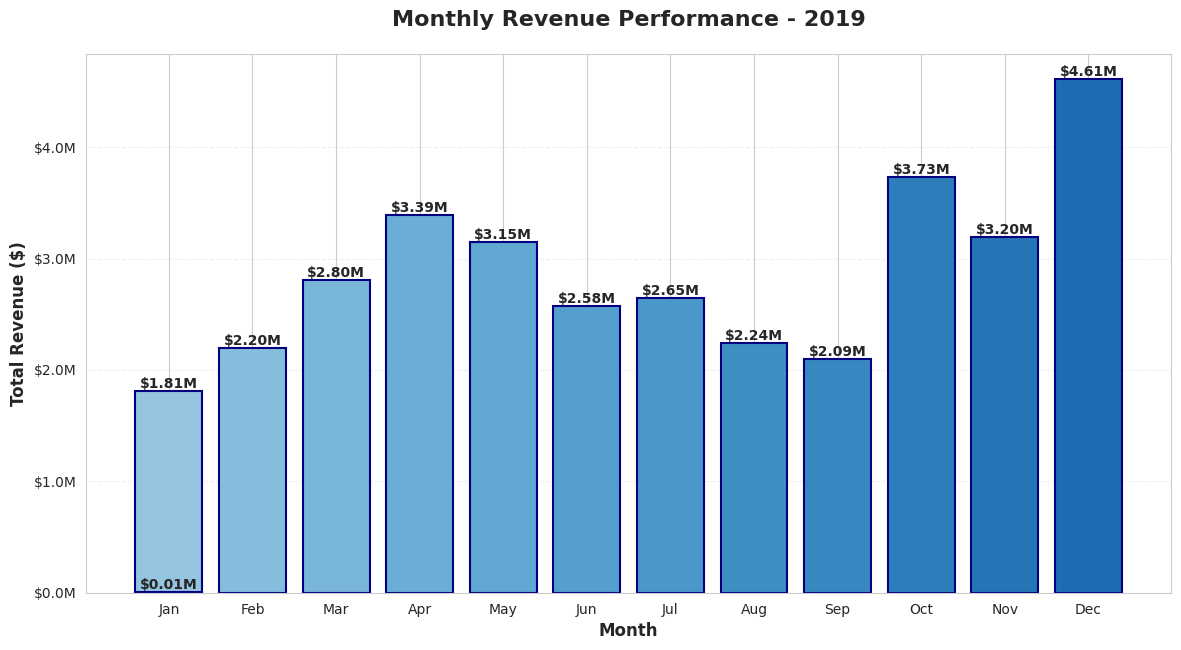

2026-02-05 01:08:09: Monthly revenue chart saved


In [2]:
logger.log("Creating monthly revenue chart...")

# Add month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_df['Month_Name'] = monthly_df['Order_Month'].apply(lambda x: month_names[int(x)-1])

# Get year
year = int(monthly_df['Order_Year'].iloc[0])

# Create chart
fig, ax = plt.subplots(figsize=(14, 7))

colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(monthly_df)))
bars = ax.bar(monthly_df['Month_Name'], monthly_df['Total_Revenue'], 
              color=colors, edgecolor='navy', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height/1e6:.2f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title(f'Monthly Revenue Performance - {year}', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Save
output_dir = Path("../analytics/reports")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"monthly_revenue_{year}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

logger.log(f"Monthly revenue chart saved")


2026-02-05 01:08:18: Creating top products chart...


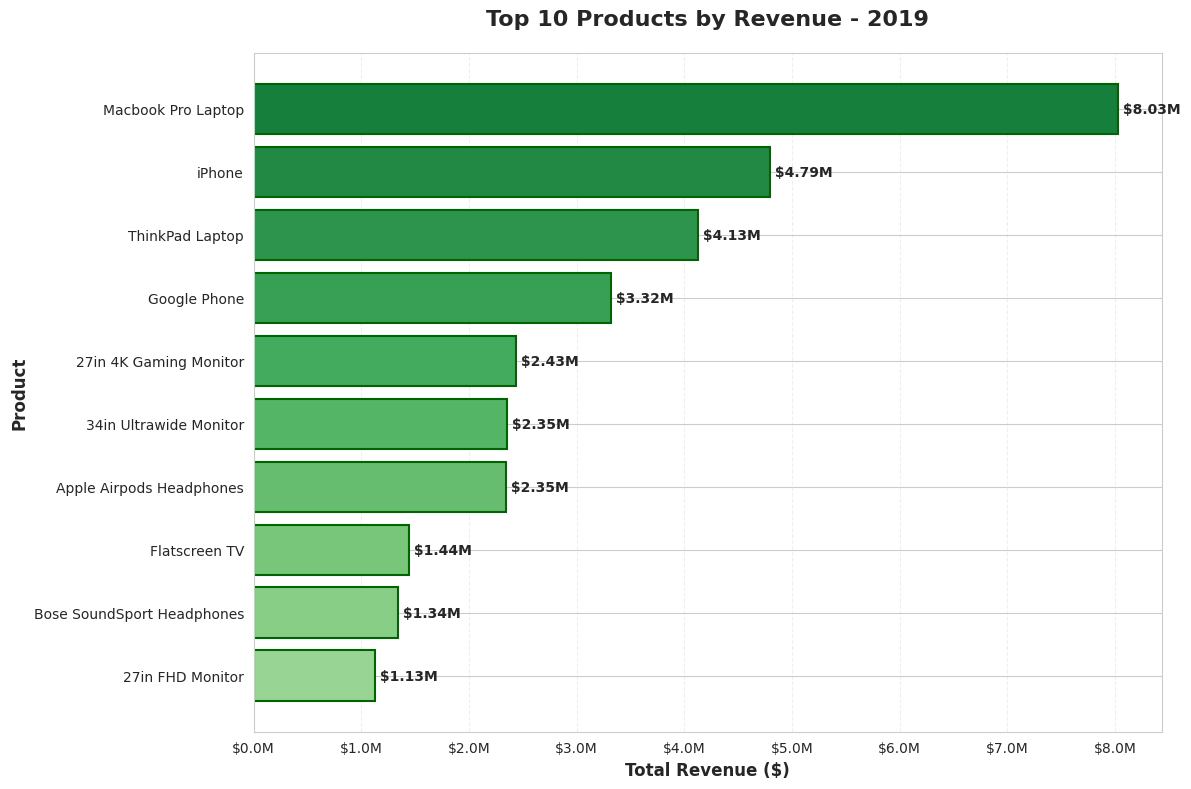

2026-02-05 01:08:18: Top products chart saved


In [3]:
logger.log("Creating top products chart...")

# Get top 10 and sort
top_10 = product_df.head(10).sort_values('Total_Revenue', ascending=True)

# Create chart
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Greens(np.linspace(0.4, 0.8, len(top_10)))
bars = ax.barh(top_10['Product'], top_10['Total_Revenue'],
               color=colors, edgecolor='darkgreen', linewidth=1.5)

# Add value labels
for bar, revenue in zip(bars, top_10['Total_Revenue']):
    ax.text(revenue, bar.get_y() + bar.get_height()/2.,
            f' ${revenue/1e6:.2f}M',
            ha='left', va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Product', fontsize=12, fontweight='bold')
ax.set_title(f'Top 10 Products by Revenue - {year}', fontsize=16, fontweight='bold', pad=20)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Save
plt.tight_layout()
plt.savefig(output_dir / f'top_products_{year}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

logger.log(f"Top products chart saved")

2026-02-05 01:08:24: Creating quarterly comparison chart...


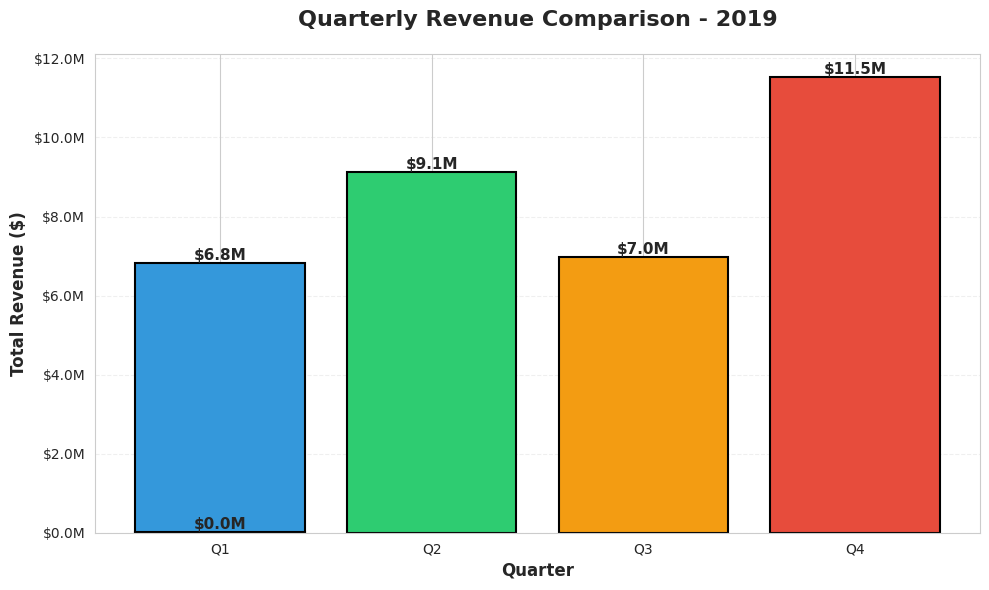

2026-02-05 01:08:25: Quarterly comparison chart saved


In [4]:
logger.log("Creating quarterly comparison chart...")

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(quarterly_df['Quarter'], quarterly_df['Total_Revenue'], 
              color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${height/1e6:.1f}M',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting
ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title(f'Quarterly Revenue Comparison - {year}', fontsize=16, fontweight='bold', pad=20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Save
plt.tight_layout()
plt.savefig(output_dir / f'quarterly_comparison_{year}.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
logger.log(f"Quarterly comparison chart saved")


In [5]:
# Print Summary 
total_revenue = monthly_df['Total_Revenue'].sum()
total_orders = monthly_df['Total_Orders'].sum()
total_units = monthly_df['Total_Units_Sold'].sum()
avg_order_value = total_revenue / total_orders

best_month = monthly_df.loc[monthly_df['Total_Revenue'].idxmax()]
worst_month = monthly_df.loc[monthly_df['Total_Revenue'].idxmin()]

summary = f"""
{'='*70}
ANNUAL SALES SUMMARY - {year}
{'='*70}

KEY METRICS:
  • Total Revenue:        ${total_revenue:,.2f}
  • Total Orders:         {int(total_orders):,}
  • Total Units Sold:     {int(total_units):,}
  • Average Order Value:  ${avg_order_value:.2f}

BEST MONTH:
  • {best_month['Month_Name']}: ${best_month['Total_Revenue']:,.2f} ({int(best_month['Total_Orders']):,} orders)

WORST MONTH:
  • {worst_month['Month_Name']}: ${worst_month['Total_Revenue']:,.2f} ({int(worst_month['Total_Orders']):,} orders)

TOP 3 PRODUCTS:
"""

for i, row in product_df.head(3).iterrows():
    summary += f"  {i+1}. {row['Product']:<35} ${row['Total_Revenue']:>12,.2f}\n"

summary += f"\n{'='*70}\n"

print(summary)

# Save summary
summary_path = output_dir.parent / 'summaries'
summary_path.mkdir(parents=True, exist_ok=True)

with open(summary_path / f'executive_summary_{year}.txt', 'w') as f:
    f.write(summary)

logger.log(f"Executive summary saved")



ANNUAL SALES SUMMARY - 2019

KEY METRICS:
  • Total Revenue:        $34,465,075.45
  • Total Orders:         178,437
  • Total Units Sold:     208,730
  • Average Order Value:  $193.15

BEST MONTH:
  • Dec: $4,608,220.13 (24,004 orders)

WORST MONTH:
  • Jan: $8,670.29 (31 orders)

TOP 3 PRODUCTS:
  1. Macbook Pro Laptop                  $8,032,500.00
  2. iPhone                              $4,792,900.00
  3. ThinkPad Laptop                     $4,127,958.72


2026-02-05 01:08:41: Executive summary saved
